# IPL 2026 - Complete Season Analysis

**By:** Your Name  
**Date:** June 2026  
**Dataset:** IPL 2026 Complete Dataset (Kaggle)

---

### What this notebook covers

IPL 2026 was a historic season. In this notebook I analyzed the complete season data to find answers to these questions:

- Who were the top performers with bat and ball?
- Which teams dominated the season?
- Which stadiums favored batting or bowling?
- What made Vaibhav Sooryavanshi the star of the season?
- How did RCB win the title despite GT being the better team on paper?

Let's dive in!


## Step 1 - Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Step 2 - Load the Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("krishd123/ipl-2026-complete-dataset")
print("Dataset downloaded at:", path)
print("\nFiles available:")
print(os.listdir(path))

100%|██████████| 125k/125k [00:00<00:00, 49.3MB/s]

Extracting files...
Dataset downloaded at: /root/.cache/kagglehub/datasets/krishd123/ipl-2026-complete-dataset/versions/12

Files available:
['bowling_stats.csv', 'squads.csv', 'fielding_stats.csv', 'deliveries.csv', 'matches.csv', 'venues.csv', 'points_table.csv', 'README.md', 'batting_stats.csv']


In [ ]:
# Loading all the CSV files

df          = pd.read_csv(os.path.join(path, 'deliveries.csv'))
df_matches  = pd.read_csv(os.path.join(path, 'matches.csv'))
df_batting  = pd.read_csv(os.path.join(path, 'batting_stats.csv'))
df_bowling  = pd.read_csv(os.path.join(path, 'bowling_stats.csv'))
df_venues   = pd.read_csv(os.path.join(path, 'venues.csv'))
df_points   = pd.read_csv(os.path.join(path, 'points_table.csv'))

print("All files loaded successfully!")
print(f"Main deliveries dataset: {df.shape}")

All files loaded successfully!
Main deliveries dataset: (17477, 19)


## Step 3 - Data Cleaning

Before starting the analysis I need to:
- Fix the date column (it was stored as text)
- Add a total_runs column
- Check for missing values and duplicates


In [ ]:
df.head()

,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
df.shape

(17477, 19)

In [ ]:
df.dtypes

,0
match_no,int64
date,object
stage,object
venue,object
batting_team,object
bowling_team,object
innings,int64
over,float64
striker,object
bowler,object


In [ ]:
# Fix date column - converting from string to datetime
df['date'] = pd.to_datetime(df['date'])

# Add two useful columns
df['total_runs'] = df['runs_of_bat'] + df['extras']
df['month'] = df['date'].dt.month_name()

print("Date column fixed:", df['date'].dtype)
print("New columns added: total_runs, month")

Date column fixed: datetime64[ns]
New columns added: total_runs, month


In [ ]:
df.isnull().sum()

,0
match_no,0
date,0
stage,0
venue,0
batting_team,0
bowling_team,0
innings,0
over,0
striker,0
bowler,0


In [ ]:
# The missing values in wicket columns are completely normal
# A wicket column will only have a value when a wicket falls
# Most balls are just runs - so most rows will be empty here

print("Duplicate rows:", df.duplicated().sum())
print("Total matches:", df['match_no'].nunique())
print("Total teams:", df['batting_team'].nunique())
print("Teams:", df['batting_team'].unique())

Duplicate rows: 0
Total matches: 74
Total teams: 10
Teams: ['SRH' 'RCB' 'KKR' 'MI' 'CSK' 'RR' 'GT' 'PBKS' 'LSG' 'DC']


## Step 4 - Season Overview

Let me get a quick summary of the entire IPL 2026 season before going deep into the analysis.


In [ ]:
total_matches = df['match_no'].nunique()
total_runs    = df['total_runs'].sum()
total_sixes   = (df['runs_of_bat'] == 6).sum()
total_fours   = (df['runs_of_bat'] == 4).sum()
total_wickets = df['wicket_type'].notna().sum()

print("=" * 45)
print("   IPL 2026 - SEASON AT A GLANCE")
print("=" * 45)
print(f"  Total Matches    : {total_matches}")
print(f"  Total Balls      : {len(df):,}")
print(f"  Total Runs       : {total_runs:,}")
print(f"  Total Sixes      : {total_sixes}")
print(f"  Total Fours      : {total_fours}")
print(f"  Total Wickets    : {total_wickets}")
print(f"  Avg Runs/Match   : {total_runs/total_matches:.1f}")
print(f"  IPL 2026 Winner  : RCB")
print("=" * 45)

   IPL 2026 - SEASON AT A GLANCE
  Total Matches    : 74
  Total Balls      : 17,477
  Total Runs       : 27,396
  Total Sixes      : 1426
  Total Fours      : 2333
  Total Wickets    : 879
  Avg Runs/Match   : 370.2
  IPL 2026 Winner  : RCB


### Runs scored each month

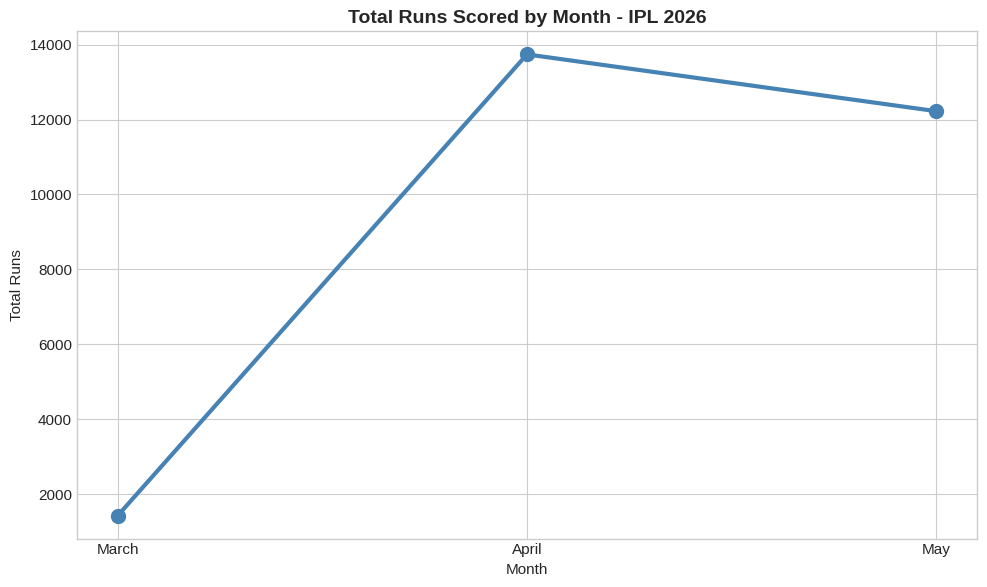

In [ ]:
month_runs = df.groupby('month')['total_runs'].sum()
month_order = ['March', 'April', 'May']
month_runs = month_runs.reindex(month_order)

plt.figure(figsize=(10, 6))
plt.plot(month_runs.index, month_runs.values, marker='o', linewidth=3, markersize=10, color='steelblue')
plt.title('Total Runs Scored by Month - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig('month_runs.png', dpi=150)
plt.show()

## Step 5 - Team Performance Analysis

Now let's see how each team performed. I'll look at runs scored, sixes hit, and wickets taken.


In [ ]:
team_runs    = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
team_sixes   = df[df['runs_of_bat'] == 6].groupby('batting_team')['runs_of_bat'].count().sort_values(ascending=False)
team_fours   = df[df['runs_of_bat'] == 4].groupby('batting_team')['runs_of_bat'].count().sort_values(ascending=False)
team_wickets = df.groupby('bowling_team')['wicket_type'].count().sort_values(ascending=False)
team_matches = df.groupby('batting_team')['match_no'].nunique().sort_values(ascending=False)

print(team_runs)

batting_team
GT      3083
RR      3071
RCB     3054
SRH     3041
PBKS    2704
DC      2552
MI      2552
CSK     2523
LSG     2505
KKR     2311
Name: total_runs, dtype: int64


In [ ]:
# Combining into one summary table
team_summary = pd.DataFrame({
    'Matches'  : team_matches,
    'Runs'     : team_runs,
    'Sixes'    : team_sixes,
    'Fours'    : team_fours,
    'Wickets'  : team_wickets
}).fillna(0).astype(int)

team_summary = team_summary.sort_values('Runs', ascending=False)
team_summary

,Matches,Runs,Sixes,Fours,Wickets
GT,17,3083,124,292,123
RR,16,3071,181,257,103
RCB,16,3054,164,261,109
SRH,15,3041,171,255,96
PBKS,13,2704,163,219,67
DC,14,2552,117,225,69
MI,14,2552,140,204,75
CSK,14,2523,124,220,81
LSG,14,2505,127,208,71
KKR,14,2311,115,192,85


### Visualization - Team Performance

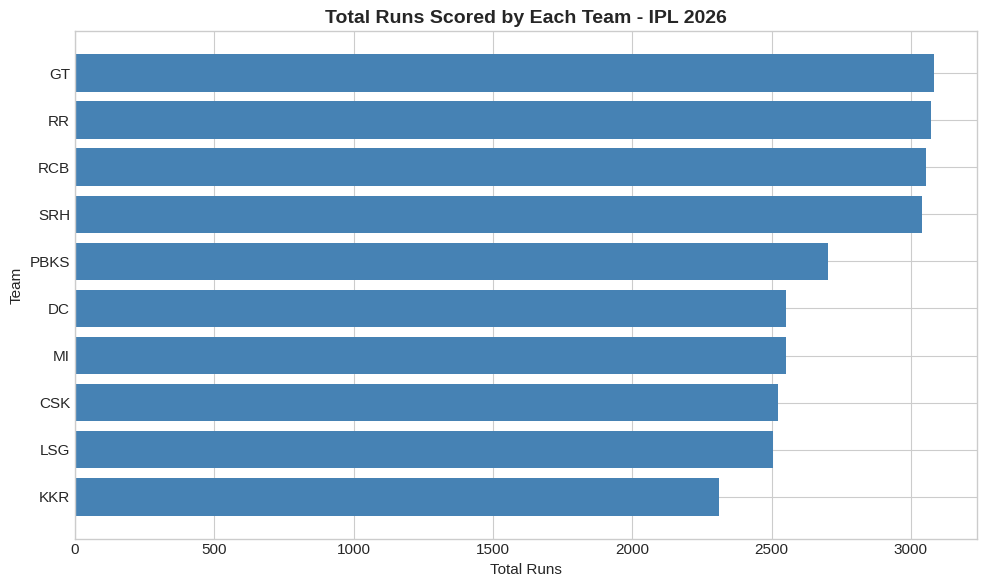

In [ ]:
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(team_runs.index, team_runs.values, color='steelblue')
plt.title('Total Runs Scored by Each Team - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Team')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('team_runs.png', dpi=150)
plt.show()

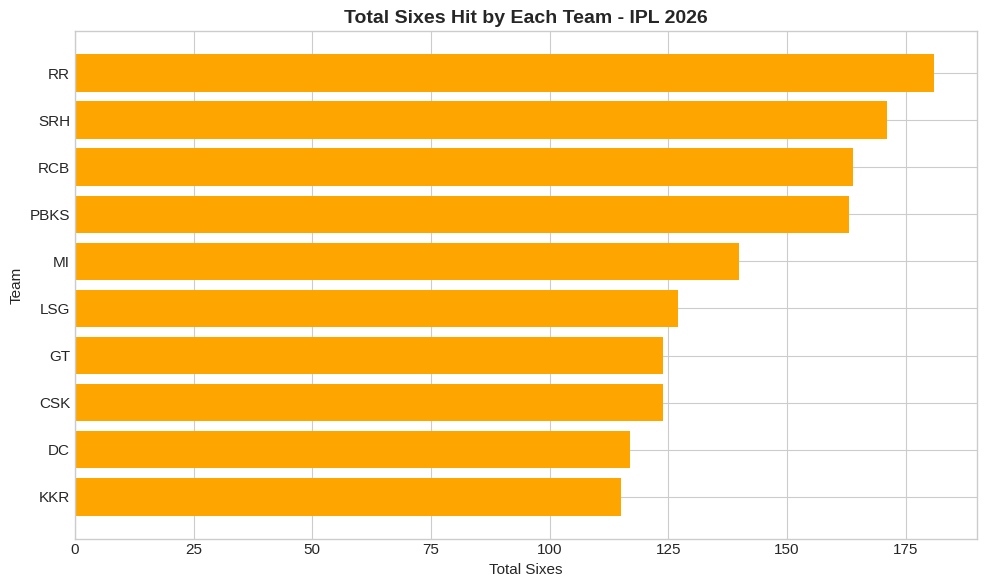

In [ ]:
team_sixes = df[df['runs_of_bat'] == 6].groupby('batting_team')['runs_of_bat'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(team_sixes.index, team_sixes.values, color='orange')
plt.title('Total Sixes Hit by Each Team - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Total Sixes')
plt.ylabel('Team')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('team_sixes.png', dpi=150)
plt.show()

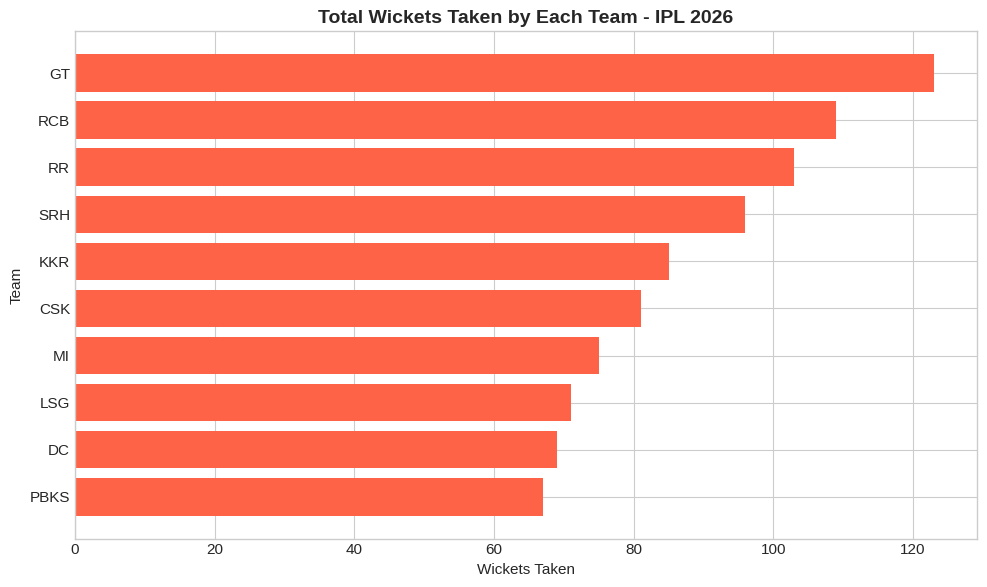

In [ ]:
team_wickets = df.groupby('bowling_team')['wicket_type'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(team_wickets.index, team_wickets.values, color='tomato')
plt.title('Total Wickets Taken by Each Team - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Wickets Taken')
plt.ylabel('Team')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('team_wickets.png', dpi=150)
plt.show()

**Observation:** GT scored most runs but RCB still won the trophy — which we will look at in detail later!

## Step 6 - Batting Analysis

Let's find the top batsmen of IPL 2026 - most runs, most sixes, best strike rates.


In [ ]:
# Top 10 run scorers
top_scorers = df.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False).head(10)
print("Top 10 Run Scorers:")
print(top_scorers)

Top 10 Run Scorers:
striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
Ishan Kishan            604
Rahul                   593
Mitchell Marsh          563
Abhishek Sharma         563
Jos Buttler             526
Name: runs_of_bat, dtype: int64


In [ ]:
# Most sixes by a player
most_sixes = df[df['runs_of_bat'] == 6].groupby('striker')['runs_of_bat'].count().sort_values(ascending=False).head(10)
print("Most Sixes:")
print(most_sixes)

Most Sixes:
striker
Vaibhav Sooryavanshi    72
Abhishek Sharma         43
Rajat Patidar           42
Ryan Rickelton          38
Mitchell Marsh          36
Shubman Gill            33
Cooper Connolly         32
Ishan Kishan            32
Priyansh Arya           32
Rahul                   31
Name: runs_of_bat, dtype: int64


In [ ]:
# Most fours by a player
most_fours = df[df['runs_of_bat'] == 4].groupby('striker')['runs_of_bat'].count().sort_values(ascending=False).head(10)
print("Most Fours:")
print(most_fours)

Most Fours:
striker
Sai Sudharsan           75
Shubman Gill            74
Virat Kohli             73
Vaibhav Sooryavanshi    63
Ishan Kishan            60
Rahul                   56
Prabhsimran Singh       55
Sanju Samson            53
Yashasvi Jaiswal        52
Jos Buttler             51
Name: runs_of_bat, dtype: int64


In [ ]:
# Strike rate - only players with 100+ balls faced
balls_faced = df.groupby('striker')['runs_of_bat'].count()
runs_scored = df.groupby('striker')['runs_of_bat'].sum()

strike_rate = (runs_scored / balls_faced * 100).round(2)
top_sr = strike_rate[balls_faced >= 100].sort_values(ascending=False).head(10)

print("Strike Rate Leaders (min 100 balls):")
print(top_sr)

Strike Rate Leaders (min 100 balls):
striker
Vaibhav Sooryavanshi    226.90
Finn Allen              207.74
Priyansh Arya           201.10
Abhishek Sharma         187.04
Rajat Patidar           182.48
Ryan Rickelton          181.38
Venkatesh Iyer          180.17
Tim David               177.33
Ishan Kishan            176.09
Donovan Ferreira        175.14
Name: runs_of_bat, dtype: float64


### Visualization - Batting Analysis

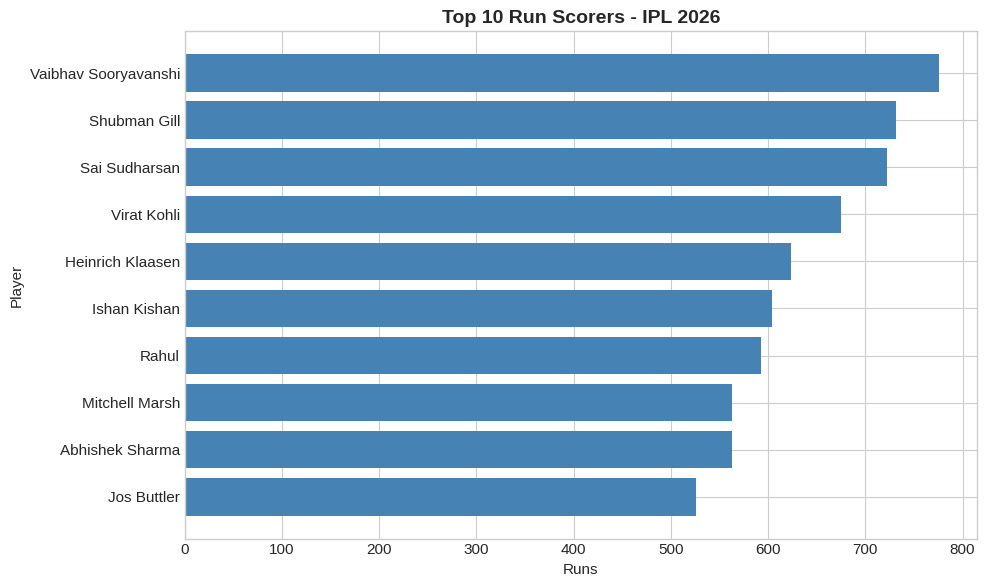

In [ ]:
top_scorers = df.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_scorers.index, top_scorers.values, color='steelblue')
plt.title('Top 10 Run Scorers - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Runs')
plt.ylabel('Player')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_scorers.png', dpi=150)
plt.show()

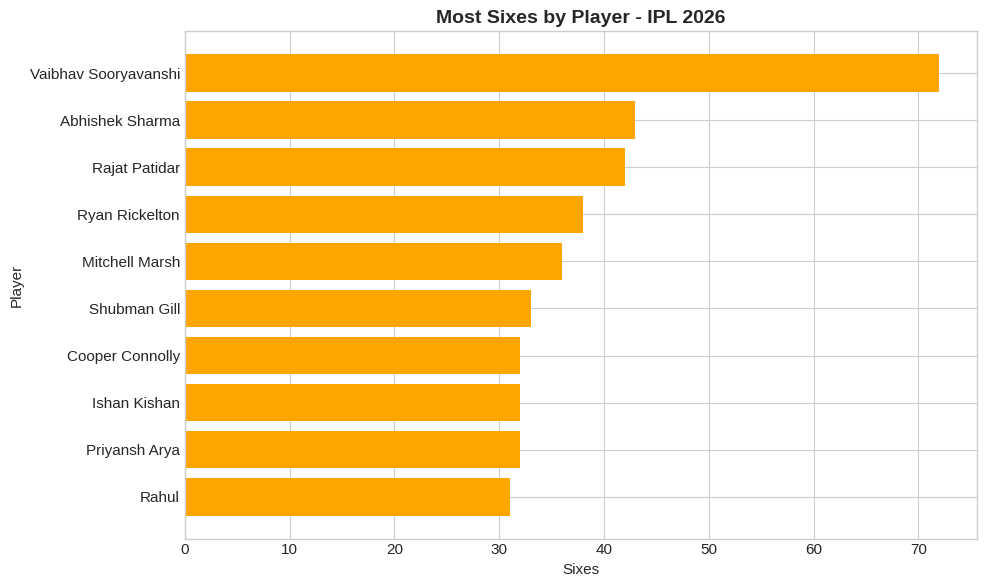

In [ ]:
most_sixes = df[df['runs_of_bat'] == 6].groupby('striker')['runs_of_bat'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(most_sixes.index, most_sixes.values, color='orange')
plt.title('Most Sixes by Player - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Sixes')
plt.ylabel('Player')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('most_sixes.png', dpi=150)
plt.show()

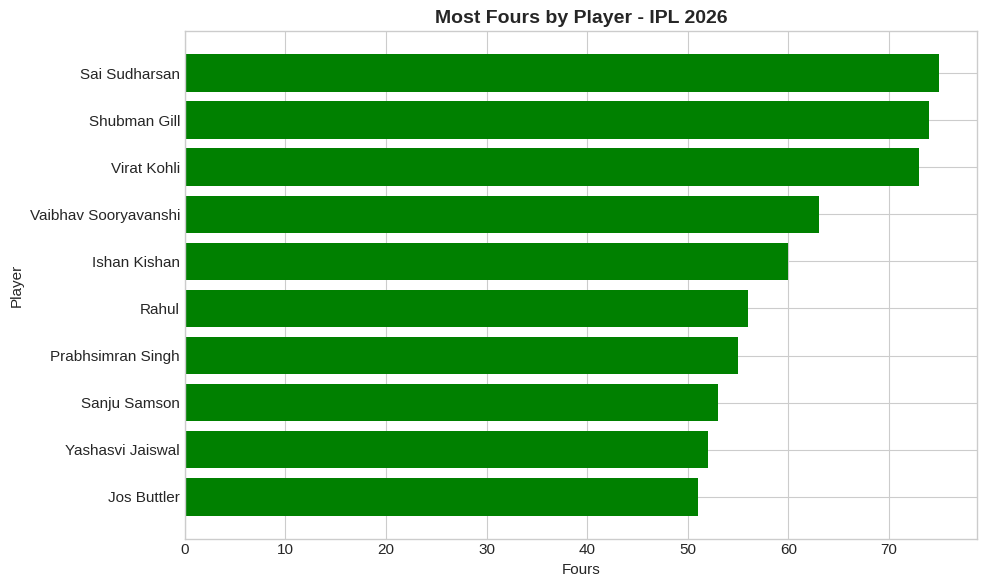

In [ ]:
most_fours = df[df['runs_of_bat'] == 4].groupby('striker')['runs_of_bat'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(most_fours.index, most_fours.values, color='green')
plt.title('Most Fours by Player - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Fours')
plt.ylabel('Player')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('most_fours.png', dpi=150)
plt.show()

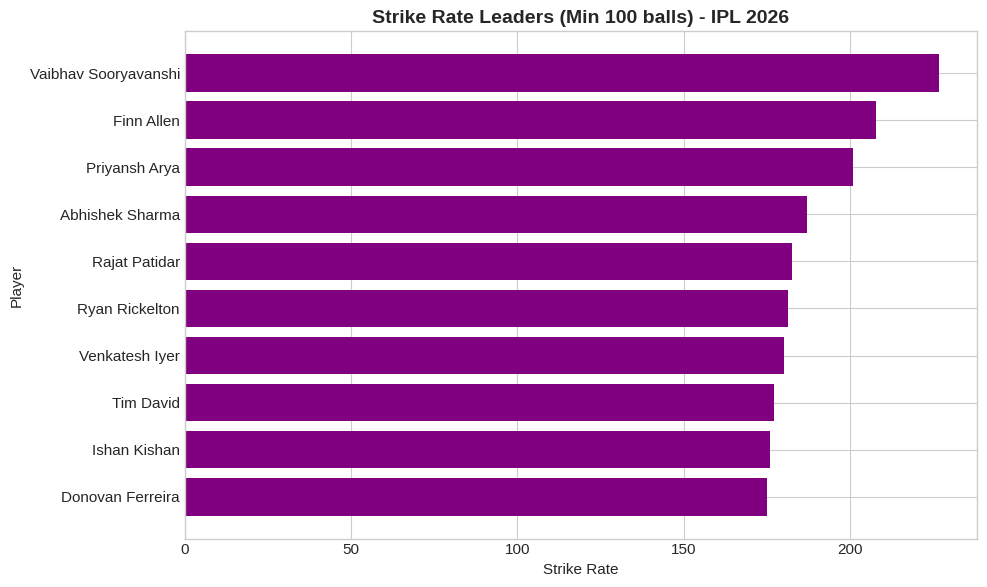

In [ ]:
balls_faced = df.groupby('striker')['runs_of_bat'].count()
runs_scored = df.groupby('striker')['runs_of_bat'].sum()
strike_rate = (runs_scored / balls_faced * 100).round(2)
top_sr = strike_rate[balls_faced >= 100].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_sr.index, top_sr.values, color='purple')
plt.title('Strike Rate Leaders (Min 100 balls) - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Player')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('strike_rate.png', dpi=150)
plt.show()

**Key Finding:** Sooryavanshi leads both the runs and sixes charts. At just 15 years old, this is extraordinary!

## Step 7 - Bowling Analysis

Now let's look at the top bowlers of IPL 2026.


In [ ]:
top_wickets = df_bowling.sort_values('wickets', ascending=False).head(10)
print(top_wickets[['bowler', 'wickets', 'economy', 'matches']].to_string(index=False))

           bowler  wickets  economy  matches
Bhuvneshwar Kumar       14     7.61        8
    Anshul Kamboj       14     8.56        8
    Eshan Malinga       14     9.44        8
     Jofra Archer       13     8.03        8
     Prince Yadav       13     8.06        8
    Kagiso Rabada       13     9.48        8
  Prasidh Krishna       12    10.34        7
     Ravi Bishnoi       11     9.54        8
      Mohsin Khan        9     6.37        4
    Krunal Pandya        9     8.85        8


In [ ]:
# Best economy rates (min 5 matches)
best_economy = df_bowling[df_bowling['matches'] >= 5].sort_values('economy').head(10)
print(best_economy[['bowler', 'economy', 'wickets', 'matches']].to_string(index=False))

           bowler  economy  wickets  matches
Bhuvneshwar Kumar     7.61       14        8
   Josh Hazlewood     7.89        8        5
   Mohammed Siraj     7.93        8        8
     Jofra Archer     8.03       13        8
     Prince Yadav     8.06       13        8
    Anshul Kamboj     8.56       14        8
    Krunal Pandya     8.85        9        8
    Eshan Malinga     9.44       14        8
    Kagiso Rabada     9.48       13        8
     Ravi Bishnoi     9.54       11        8


### Visualization - Bowling Analysis

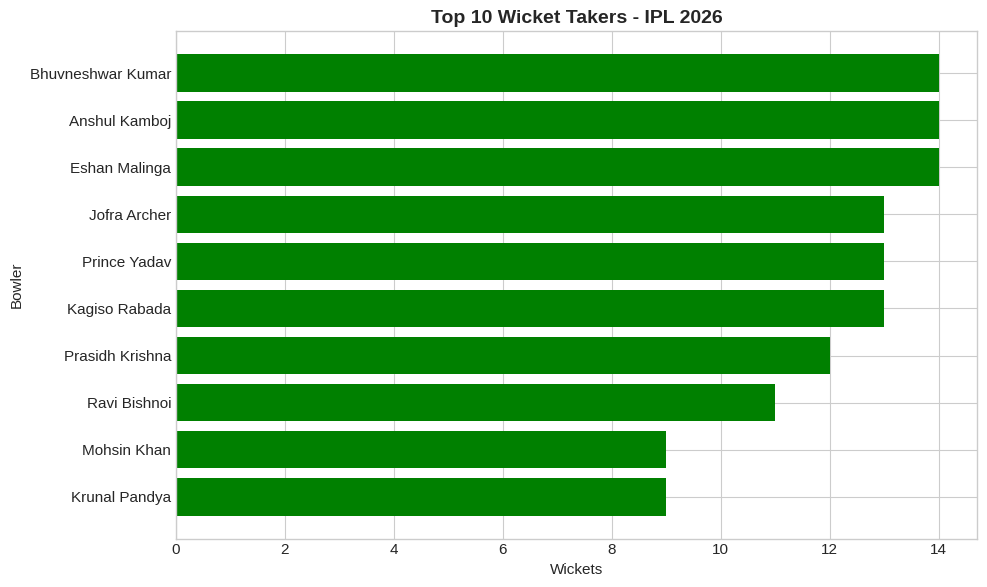

In [ ]:
top_wickets = df_bowling.sort_values('wickets', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_wickets['bowler'], top_wickets['wickets'], color='green')
plt.title('Top 10 Wicket Takers - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_wickets.png', dpi=150)
plt.show()

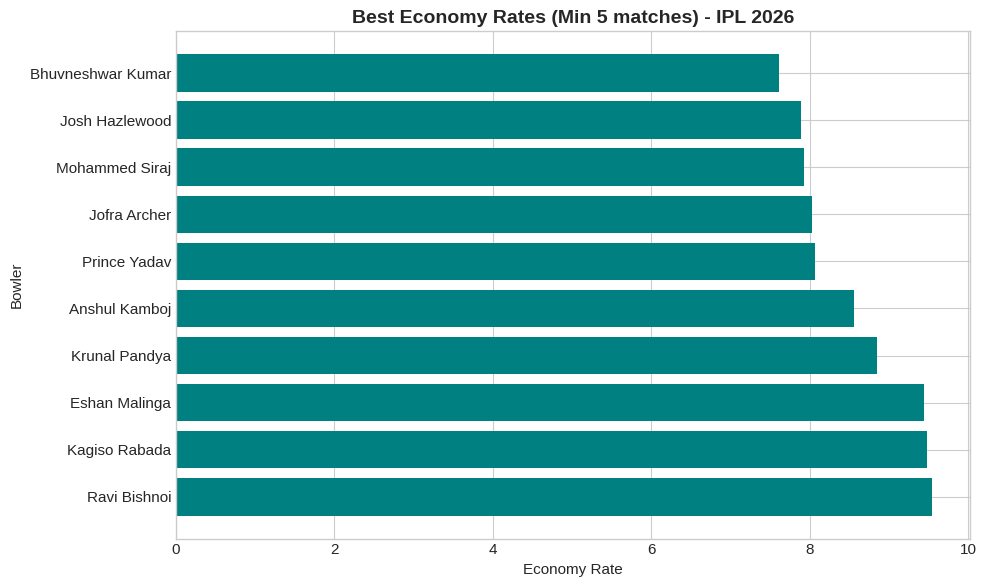

In [ ]:
best_economy = df_bowling[df_bowling['matches'] >= 5].sort_values('economy').head(10)

plt.figure(figsize=(10, 6))
plt.barh(best_economy['bowler'], best_economy['economy'], color='teal')
plt.title('Best Economy Rates (Min 5 matches) - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('best_economy.png', dpi=150)
plt.show()

**Key Finding:** Bhuvneshwar Kumar was best in every bowling category — most wickets, best economy and best average. Complete bowler!

## Step 8 - Venue Analysis

Different stadiums produce very different matches.  
Let's find which venues were best for batting and which helped bowlers.


In [ ]:
venue_runs    = df.groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(10)
venue_sixes   = df[df['runs_of_bat'] == 6].groupby('venue')['runs_of_bat'].count().sort_values(ascending=False).head(8)
venue_wickets = df.groupby('venue')['wicket_type'].count().sort_values(ascending=False).head(8)
venue_avg     = (df.groupby('venue')['total_runs'].sum() /
                 df.groupby('venue')['match_no'].nunique()).sort_values(ascending=False).head(8)

print("Average runs per match by venue:")
print(venue_avg.round(1))

Average runs per match by venue:
venue
Sawai Mansingh Stadium, Jaipur                                                        432.0
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh    423.5
Wankhede Stadium, Mumbai                                                              419.0
Himachal Pradesh Cricket Association Stadium, Dharamsala                              416.2
Rajiv Gandhi International Stadium, Hyderabad                                         389.1
M.Chinnaswamy Stadium, Bengaluru                                                      384.6
MA Chidambaram Stadium, Chennai                                                       367.7
Shaheed Veer Narayan Singh International Stadium, Raipur                              359.0
dtype: float64


### Visualization - Venue Analysis

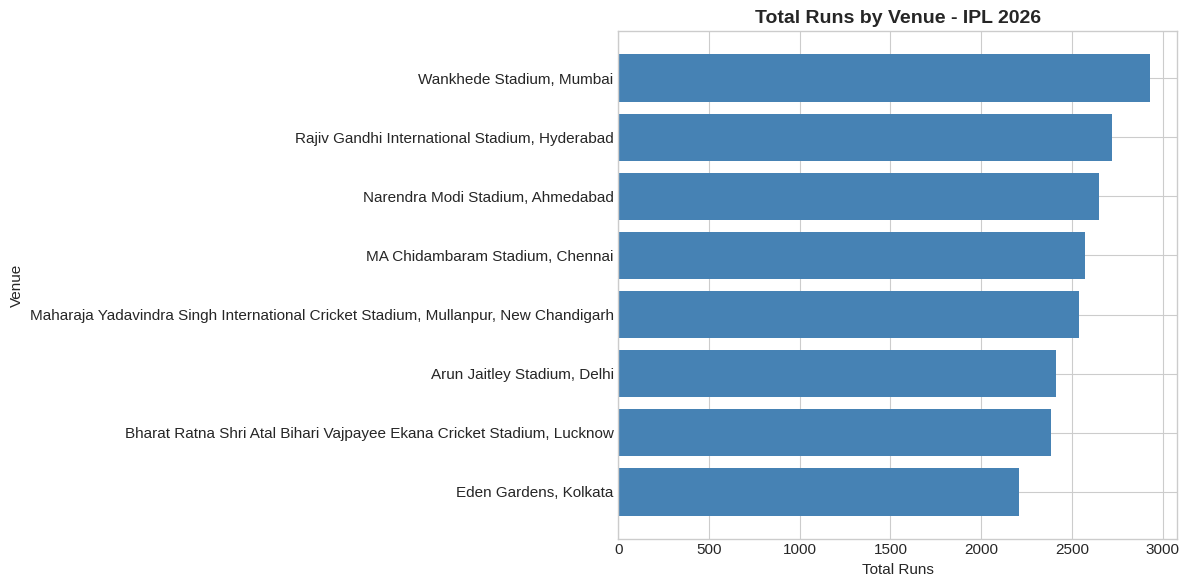

In [ ]:
venue_runs = df.groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 6))
plt.barh(venue_runs.index, venue_runs.values, color='steelblue')
plt.title('Total Runs by Venue - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Venue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('venue_runs.png', dpi=150)
plt.show()

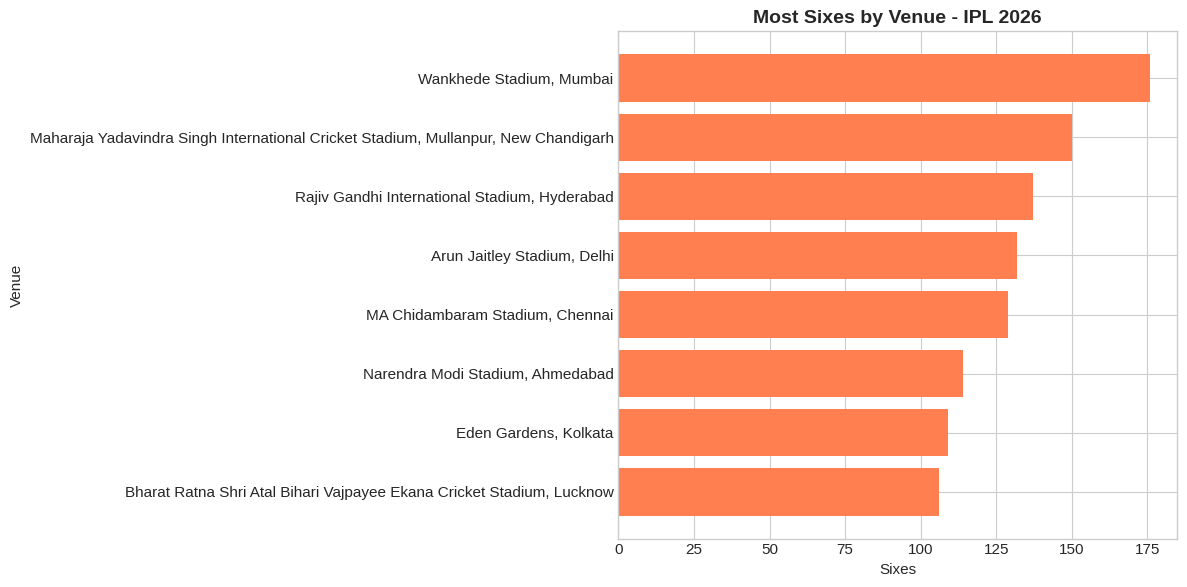

In [ ]:
venue_sixes = df[df['runs_of_bat'] == 6].groupby('venue')['runs_of_bat'].count().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 6))
plt.barh(venue_sixes.index, venue_sixes.values, color='coral')
plt.title('Most Sixes by Venue - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Sixes')
plt.ylabel('Venue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('venue_sixes.png', dpi=150)
plt.show()

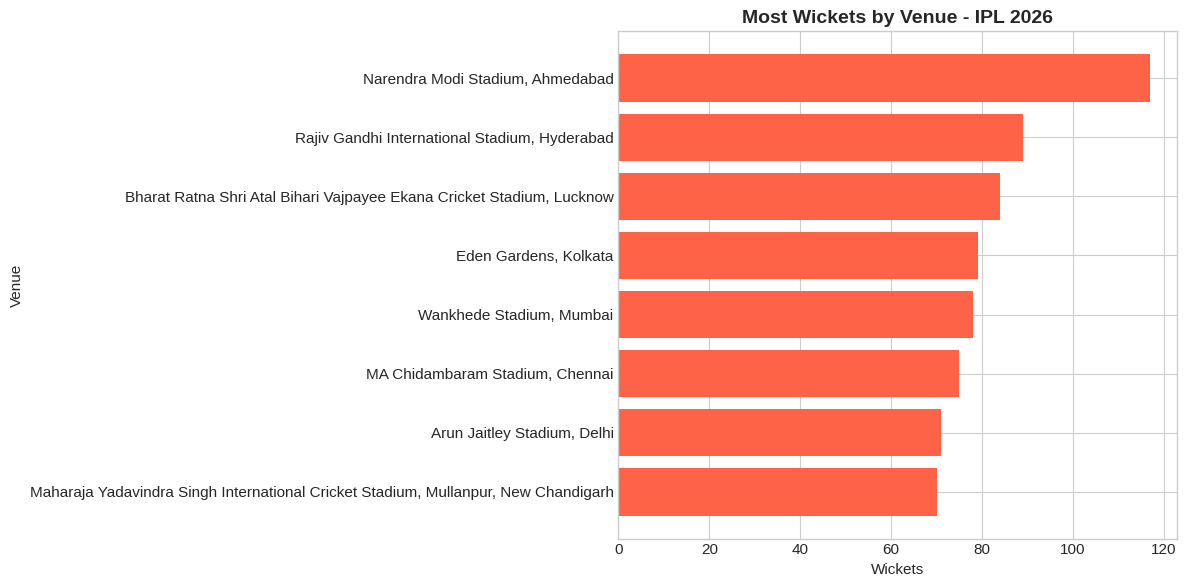

In [ ]:
venue_wickets = df.groupby('venue')['wicket_type'].count().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 6))
plt.barh(venue_wickets.index, venue_wickets.values, color='tomato')
plt.title('Most Wickets by Venue - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Wickets')
plt.ylabel('Venue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('venue_wickets.png', dpi=150)
plt.show()

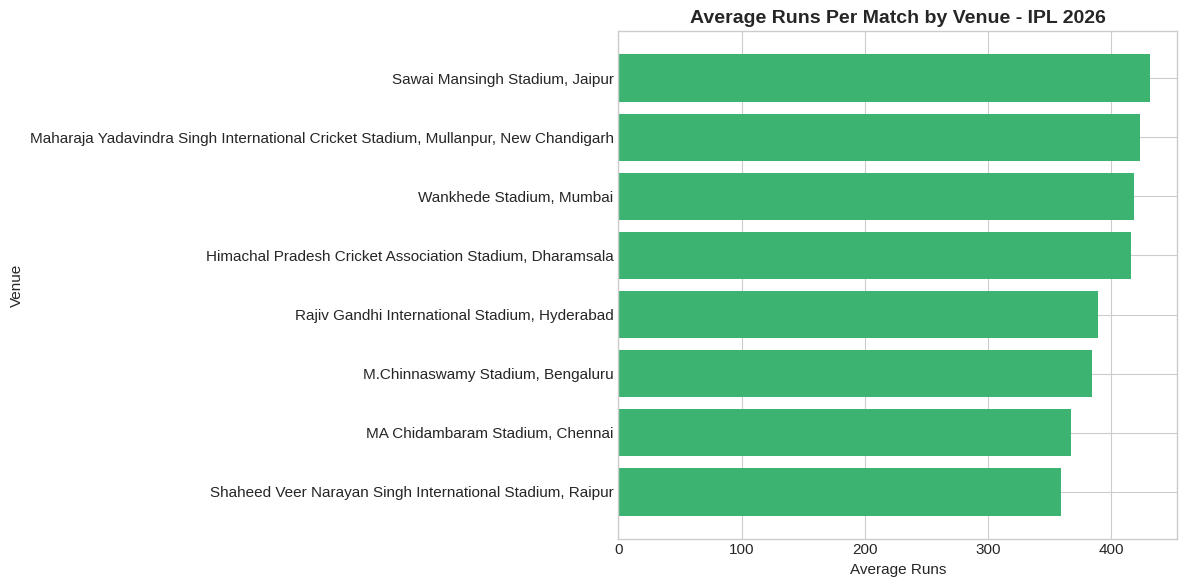

In [ ]:
venue_avg = (df.groupby('venue')['total_runs'].sum() /
              df.groupby('venue')['match_no'].nunique()).sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 6))
plt.barh(venue_avg.index, venue_avg.values, color='mediumseagreen')
plt.title('Average Runs Per Match by Venue - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Average Runs')
plt.ylabel('Venue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('venue_avg.png', dpi=150)
plt.show()

**Key Finding:**
- Wankhede Stadium Mumbai = Best batting ground (most sixes, most runs)
- Narendra Modi Stadium Ahmedabad = Best bowling ground (most wickets)


## Step 9 - Vaibhav Sooryavanshi Special Analysis

The biggest story of IPL 2026. A 15-year-old who broke every record.  
Let's look at his numbers in detail and compare him with the other top batsmen.


In [ ]:
surya = df_batting[df_batting['batsman'].str.contains('Sooryavanshi', case=False)].iloc[0]

print("VAIBHAV SOORYAVANSHI - IPL 2026 STATS")
print("-" * 40)
print(f"Team         : Rajasthan Royals")
print(f"Age          : 15 Years")
print(f"Matches      : {surya['matches']}")
print(f"Runs         : {surya['runs']} (Orange Cap)")
print(f"Strike Rate  : {surya['strike_rate']} (Highest in IPL 2026)")
print(f"Average      : {surya['average']}")
print(f"Sixes        : {surya['sixes']} (Most in IPL 2026)")
print(f"Fours        : {surya['fours']}")
print(f"High Score   : {surya['high_score']}")
print(f"Centuries    : {surya['hundreds']}")
print(f"Fifties      : {surya['fifties']}")

VAIBHAV SOORYAVANSHI - IPL 2026 STATS
----------------------------------------
Team         : Rajasthan Royals
Age          : 15 Years
Matches      : 8
Runs         : 357 (Orange Cap)
Strike Rate  : 234.86 (Highest in IPL 2026)
Average      : 44.62
Sixes        : 32 (Most in IPL 2026)
Fours        : 31
High Score   : 103
Centuries    : 1
Fifties      : 2


In [ ]:
# Compare Sooryavanshi with top 6 batsmen
top6 = df_batting.sort_values('runs', ascending=False).head(6)
print(top6[['batsman', 'runs', 'strike_rate', 'average', 'sixes', 'balls_faced']].to_string(index=False))

             batsman  runs  strike_rate  average  sixes  balls_faced
     Abhishek Sharma   380       212.29    54.28     28          179
            KL Rahul   358       185.49    51.14     19          193
Vaibhav Sooryavanshi   357       234.86    44.62     32          152
         Virat Kohli   351       162.50    58.50     14          216
    Heinrich Klaasen   349       149.78    49.85     14          233
        Shubman Gill   330       148.64    47.14     14          222


In [ ]:
# The most interesting comparison - runs scored vs balls used
print("\nWho scored more in fewer balls?")
print("-" * 55)
for _, row in top6.iterrows():
    print(f"{row['batsman']:<25} {row['runs']} runs from {row['balls_faced']} balls")


Who scored more in fewer balls?
-------------------------------------------------------
Abhishek Sharma           380 runs from 179 balls
KL Rahul                  358 runs from 193 balls
Vaibhav Sooryavanshi      357 runs from 152 balls
Virat Kohli               351 runs from 216 balls
Heinrich Klaasen          349 runs from 233 balls
Shubman Gill              330 runs from 222 balls


### Visualization - Sooryavanshi vs Top Batsmen

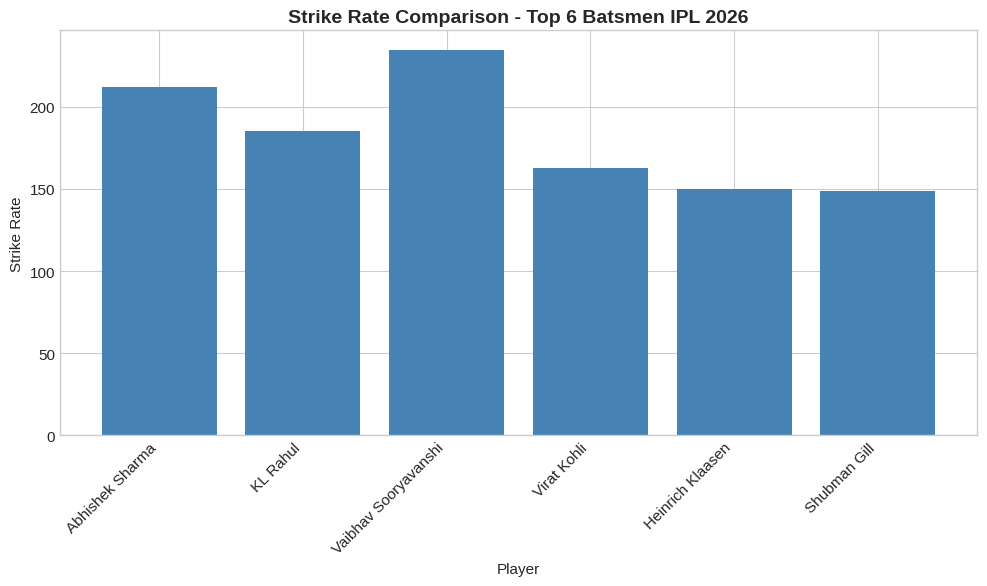

In [ ]:
top6 = df_batting.sort_values('runs', ascending=False).head(6)

plt.figure(figsize=(10, 6))
plt.bar(top6['batsman'], top6['strike_rate'], color='steelblue')
plt.title('Strike Rate Comparison - Top 6 Batsmen IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Player')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('strike_rate_comparison.png', dpi=150)
plt.show()

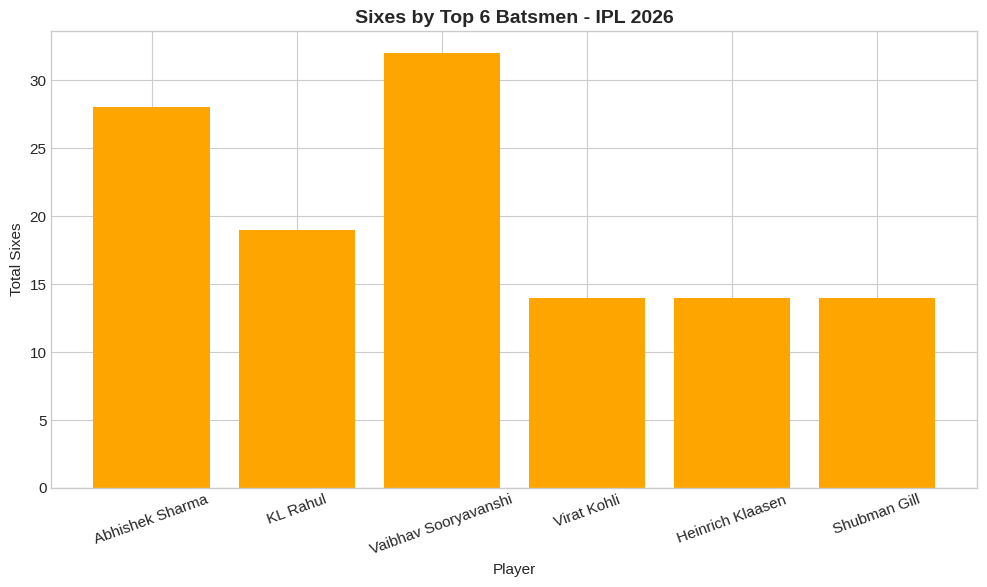

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(top6['batsman'], top6['sixes'], color='orange')
plt.title('Sixes by Top 6 Batsmen - IPL 2026', fontsize=14, fontweight='bold')
plt.xlabel('Player')
plt.ylabel('Total Sixes')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('top6_sixes.png', dpi=150)
plt.show()

**The Numbers Tell the Story:**

Sooryavanshi scored 776 runs from just 342 balls.  
Sai Sudharsan needed 479 balls to score 722 runs.  
That is 137 extra balls to score 54 fewer runs.  
This is what a Strike Rate of 234 means in real terms.


## Step 10 - The RCB Story

GT were better in almost every stat. Yet RCB won the trophy.  
Let's compare them properly and understand what happened.


In [ ]:
rcb_runs    = df[df['batting_team'] == 'RCB']['total_runs'].sum()
gt_runs     = df[df['batting_team'] == 'GT']['total_runs'].sum()
rcb_wickets = df[df['bowling_team'] == 'RCB']['wicket_type'].count()
gt_wickets  = df[df['bowling_team'] == 'GT']['wicket_type'].count()
rcb_sixes   = df[(df['batting_team'] == 'RCB') & (df['runs_of_bat'] == 6)].shape[0]
gt_sixes    = df[(df['batting_team'] == 'GT') & (df['runs_of_bat'] == 6)].shape[0]
rcb_matches = df[df['batting_team'] == 'RCB']['match_no'].nunique()
gt_matches  = df[df['batting_team'] == 'GT']['match_no'].nunique()

print("GT vs RCB - Full Season Comparison")
print("=" * 45)
print(f"{'Stat':<20} {'GT':>10} {'RCB':>10}")
print("-" * 45)
print(f"{'Runs Scored':<20} {gt_runs:>10,} {rcb_runs:>10,}")
print(f"{'Sixes Hit':<20} {gt_sixes:>10} {rcb_sixes:>10}")
print(f"{'Wickets Taken':<20} {gt_wickets:>10} {rcb_wickets:>10}")
print(f"{'Matches Played':<20} {gt_matches:>10} {rcb_matches:>10}")
print(f"{'Trophy':<20} {'NO':>10} {'YES':>10}")
print("=" * 45)

GT vs RCB - Full Season Comparison
Stat                         GT        RCB
---------------------------------------------
Runs Scored               3,083      3,054
Sixes Hit                   124        164
Wickets Taken               123        109
Matches Played               17         16
Trophy                       NO        YES


In [ ]:
print("IPL 2026 FINAL")
print("-" * 40)
print("Date    : May 31, 2026")
print("Venue   : Narendra Modi Stadium, Ahmedabad")
print("GT      : 155/8 (20 overs)")
print("RCB     : 161/5 (18 overs) - Won by 5 wickets")
print("POTM    : Virat Kohli - 75* off 42 balls")
print()
print("Kohli all season average SR : 162")
print("Kohli SR in the Final       : 178")
print()
print("He saved his best for the biggest match.")

IPL 2026 FINAL
----------------------------------------
Date    : May 31, 2026
Venue   : Narendra Modi Stadium, Ahmedabad
GT      : 155/8 (20 overs)
RCB     : 161/5 (18 overs) - Won by 5 wickets
POTM    : Virat Kohli - 75* off 42 balls

Kohli all season average SR : 162
Kohli SR in the Final       : 178

He saved his best for the biggest match.


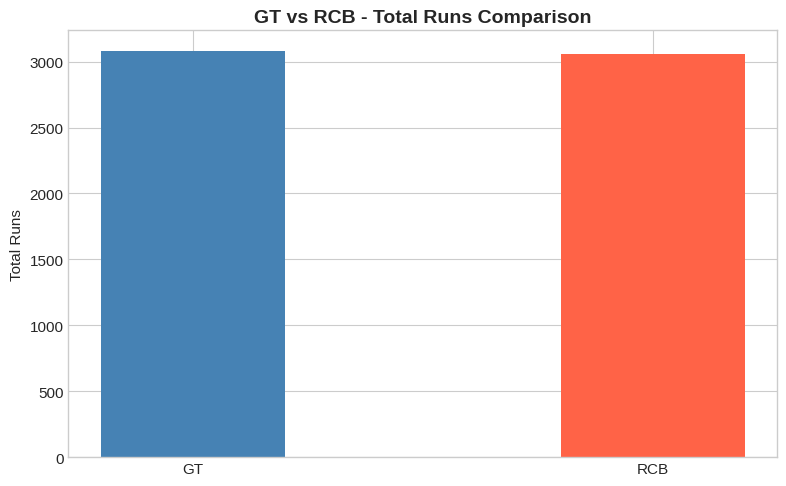

In [ ]:
teams = ['GT', 'RCB']
runs  = [gt_runs, rcb_runs]

plt.figure(figsize=(8, 5))
plt.bar(teams, runs, color=['steelblue', 'tomato'], width=0.4)
plt.title('GT vs RCB - Total Runs Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig('gt_vs_rcb.png', dpi=150)
plt.show()

## Step 11 - Key Insights

In [ ]:
print("IPL 2026 - KEY INSIGHTS SUMMARY")
print("=" * 50)
print()
print("1. ORANGE CAP")
print("   Vaibhav Sooryavanshi - 776 runs, SR 234, 72 sixes")
print("   Only 15 years old. Youngest Orange Cap winner ever.")
print()
print("2. PURPLE CAP")
print("   Three way tie - Bhuvneshwar, Kamboj, Malinga (14 wkts each)")
print("   Bhuvneshwar also had the best economy (7.61)")
print()
print("3. BEST TEAM BY STATS")
print("   Gujarat Titans - 3083 runs, 123 wickets, 17 matches")
print("   But they lost the final to RCB")
print()
print("4. VENUES")
print("   Best batting : Wankhede Mumbai")
print("   Best bowling : Narendra Modi Stadium Ahmedabad")
print("   Highest avg  : Sawai Mansingh Jaipur (432 per match)")
print()
print("5. BIGGEST STORY")
print("   GT dominated every stat - RCB won the trophy")
print("   Kohli hit 75* in the Final at a bowling ground")
print("   RCB are back to back champions - only 3rd team ever")
print()
print("6. SEASON NUMBERS")
print("   62 matches, 17477 balls, 879 wickets, March to May 2026")

IPL 2026 - KEY INSIGHTS SUMMARY

1. ORANGE CAP
   Vaibhav Sooryavanshi - 776 runs, SR 234, 72 sixes
   Only 15 years old. Youngest Orange Cap winner ever.

2. PURPLE CAP
   Three way tie - Bhuvneshwar, Kamboj, Malinga (14 wkts each)
   Bhuvneshwar also had the best economy (7.61)

3. BEST TEAM BY STATS
   Gujarat Titans - 3083 runs, 123 wickets, 17 matches
   But they lost the final to RCB

4. VENUES
   Best batting : Wankhede Mumbai
   Best bowling : Narendra Modi Stadium Ahmedabad
   Highest avg  : Sawai Mansingh Jaipur (432 per match)

5. BIGGEST STORY
   GT dominated every stat - RCB won the trophy
   Kohli hit 75* in the Final at a bowling ground
   RCB are back to back champions - only 3rd team ever

6. SEASON NUMBERS
   62 matches, 17477 balls, 879 wickets, March to May 2026


## Conclusion

This analysis of IPL 2026 had some great stories hidden inside the data.

The biggest one is Vaibhav Sooryavanshi. A 15 year old scoring 776 runs at a strike rate of 234 is something nobody has ever seen in IPL history.

The second biggest story is RCB. Gujarat Titans were statistically the best team all season. They scored more runs, took more wickets and played more matches. But on the final day at Ahmedabad, Virat Kohli showed why experience and big match temperament matter more than season stats.

Data tells you what happened. But cricket reminds you that numbers never tell the full story.

---

Thank you for reading! If you found this useful please upvote.

GitHub: [https://github.com/sidducv0528]  
LinkedIn: [https://www.linkedin.com/in/siddu-data/]
